# Week 7: American Put as an RL Exercise/Hold Problem
## MDP Formulation, Environment, and Baseline Policy Comparison

**Author:** Sarthak Somani
**Objective:** Formulate American put early exercise as a Markov Decision Process,
implement and test a Gym-style hold/exercise environment, and compare baseline and
tabular Q-learning exercise policies against the Week 4 binomial exercise boundary.

This week's deliverable is the **formulation**, not a fully trained agent -- Week 8
trains a stronger policy on top of what's built here.


## Part A -- MDP Definition

| Component | Definition |
|---|---|
| **State** `s` | `[time_fraction, moneyness] = [step / steps, S_t / K]` |
| **Actions** `a` | `0 = hold`, `1 = exercise` |
| **Transition** `P` | Hold: one risk-neutral CRR binomial step (`S <- S*u` w.p. `p`, else `S <- S*d`). Exercise: episode ends. |
| **Reward** `R` | `0.0` on every hold step; `max(K - S_t, 0)` exactly once, at exercise or forced expiry-exercise. |
| **Discount** `gamma` | `exp(-r * dt)` per step -- the finance present-value convention. |
| **Terminal condition** | Exercise, or `step == steps` (auto-exercised at expiry if in the money). |

**No lookahead leakage:** the state `[time_fraction, moneyness]` is a function only of
the *current* step and *current* spot -- both already realized when the agent acts.
`AmericanPutEnv.step()` only draws the next spot *after* the hold/exercise decision is
made, so the policy never has access to a future price. The transition uses the
risk-neutral probability `p` (not physical drift), because we want simulated returns to
be pricing-consistent with the Week 4 tree rather than a real-world price forecast.


In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.join("..", "binomial-tree"))
import numpy as np
import matplotlib.pyplot as plt

from american_put import crr_put_price, crr_put_with_boundary

from environment import AmericanPutEnv
from policies import (
    always_hold_policy,
    immediate_exercise_policy,
    make_random_policy,
    make_q_policy,
    discretize_state,
)
from evaluate import (
    run_policy,
    policy_exercise_region,
    policy_q_margin,
    boundary_to_moneyness,
    plot_exercise_region,
    plot_q_margin,
    plot_exercise_step_histogram,
)
from q_learning import train_q_learning

ENV_KWARGS = dict(S0=100.0, K=100.0, T=1.0, r=0.05, sigma=0.25, steps=50)
ENV_KWARGS


{'S0': 100.0, 'K': 100.0, 'T': 1.0, 'r': 0.05, 'sigma': 0.25, 'steps': 50}

## Part B -- Environment

`AmericanPutEnv` (`environment.py`) exposes `reset()` / `step(action)`. Its `done` flag
blocks any step after exercise or expiry, reward is `0.0` on every hold step and
non-negative exactly once at the stopping step, and invalid actions raise `ValueError`.
`reset()` also accepts an optional `step_count`/`spot` override for "exploring starts,"
used later in this notebook to train the Q-learner -- omitting them (the normal case)
starts the episode at contract inception, `t=0, S=S0`.

### Five sample episodes (random hold/exercise policy)

A pure random policy exercises almost immediately in expectation (mean ~2 steps for a
fair coin), so it rarely survives long enough to demonstrate expiry-side termination.
An always-hold episode is shown alongside for contrast.


In [2]:
env = AmericanPutEnv(**ENV_KWARGS, seed=11)
random_policy = make_random_policy(seed=11)

print("Five sample episodes (random policy):")
for i in range(5):
    state = env.reset()
    done = False
    while not done:
        action = random_policy(state)
        state, reward, done, info = env.step(action)
    print(f"  episode {i}: reason={info['reason']}, step={info['step']}, "
          f"reward={reward:.4f}, final moneyness={state[1]:.4f}")

# Random policies rarely survive to expiry -- show expiry termination via always-hold.
state = env.reset()
done = False
while not done:
    state, reward, done, info = env.step(env.HOLD)
print(f"  (always-hold, for contrast): reason={info['reason']}, step={info['step']}, "
      f"reward={reward:.4f}, final moneyness={state[1]:.4f}")


Five sample episodes (random policy):
  episode 0: reason=exercise, step=2, reward=0.0000, final moneyness=1.0733
  episode 1: reason=exercise, step=1, reward=3.4738, final moneyness=0.9653
  episode 2: reason=exercise, step=0, reward=0.0000, final moneyness=1.0000
  episode 3: reason=exercise, step=0, reward=0.0000, final moneyness=1.0000
  episode 4: reason=exercise, step=4, reward=0.0000, final moneyness=1.0733
  (always-hold, for contrast): reason=expiry, step=50, reward=0.0000, final moneyness=1.1519


### Environment invariant tests

`test_environment.py` has 19 tests: the two required invariants (non-negative payoff,
cannot-step-after-done) plus no-leakage state shape, zero reward on hold, correct
expiry termination/payoff, invalid-action rejection, random-policy always terminates,
discounted value never exceeds raw payoff, non-uniform state-binning behavior,
exploring-start reset validity, the warmup-then-refine schedule (fraction=0.0 matches
exploring_starts=False; a moderate budget achieves full table coverage), and
Q-learning smoke tests (finite table, valid greedy action, exploring starts reach
far-from-the-money states). Run from a shell in this directory:

```bash
pytest test_environment.py -v
```

All 19 pass. The next cell runs them inline for the report.


In [3]:
import subprocess

result = subprocess.run(
    [sys.executable, "-m", "pytest", "test_environment.py", "-v"],
    capture_output=True, text=True,
)
print(result.stdout[-2500:])
print(result.stderr[-500:] if result.returncode != 0 else "")


rmup=False warmup_iterations=100000)
rootdir: C:\Users\soman\OneDrive\Coding\SOC 2026\week7-rl-formulation
plugins: anyio-4.11.0, langsmith-0.6.4, asyncio-1.3.0, benchmark-5.2.3, codspeed-4.3.0, recording-0.13.4, socket-0.7.0, syrupy-5.1.0
asyncio: mode=Mode.STRICT, debug=False, asyncio_default_fixture_loop_scope=None, asyncio_default_test_loop_scope=function
collecting ... collected 19 items

test_environment.py::test_state_has_no_leakage PASSED                    [  5%]
test_environment.py::test_exercise_payoff_nonnegative_and_exact PASSED   [ 10%]
test_environment.py::test_cannot_step_after_done PASSED                  [ 15%]
test_environment.py::test_invalid_action_rejected PASSED                 [ 21%]
test_environment.py::test_hold_never_pays_reward_until_terminal PASSED   [ 26%]
test_environment.py::test_episode_terminates_at_expiry_with_correct_payoff PASSED [ 31%]
test_environment.py::test_random_policy_always_terminates PASSED         [ 36%]
test_environment.py::test_immediat

## Part C -- Policy Comparison

Baseline contract: `S0=K=100, T=1, r=5%, sigma=25%`, 50 binomial steps. First, the
Week 4 CRR binomial reference price and exercise boundary on the same 50-step grid.


In [4]:
ref_price, ref_boundary = crr_put_with_boundary(**ENV_KWARGS)
euro_price = crr_put_price(**ENV_KWARGS, american=False)
ref_t, ref_m = boundary_to_moneyness(ref_boundary, ENV_KWARGS["T"], ENV_KWARGS["K"])

print(f"Week 4 binomial American put price (50 steps): {ref_price:.4f}")
print(f"Week 4 binomial European put price (50 steps): {euro_price:.4f}")


Week 4 binomial American put price (50 steps): 7.9520
Week 4 binomial European put price (50 steps): 7.4096


### Train the tabular Q-learning prototype -- warmup-then-refine

Epsilon-greedy tabular Q-learning (`q_learning.py`) on a 20 (time) x 30 (moneyness)
discretized grid. Moneyness bins are **non-uniform**: fine across [0.7, 1.0], where the
true exercise boundary actually lives, coarser outside (`policies.DEFAULT_MONEY_EDGES`).

Training uses a **warmup-then-refine** schedule by default (`exploring_start_fraction
=0.5`): the first half of episodes reset to a state drawn uniformly over
(time, moneyness) -- "exploring starts" -- and the remaining half reset normally at
contract inception. The cell below shows why a *pure* exploring-starts schedule isn't
enough on its own -- it trains three variants at a shared episode budget and counts how
many of the 600 `(time, moneyness)` cells are never visited by either action, and how
each variant's resulting policy scores.


In [5]:
from policies import DEFAULT_MONEY_EDGES, MONEY_MIN, MONEY_MAX

def count_unvisited_cells(env_kwargs, exploring_starts, exploring_start_fraction=0.5, episodes=20000, seed=123):
    train_env = AmericanPutEnv(**env_kwargs, seed=42)
    n_time, n_money = 20, len(DEFAULT_MONEY_EDGES) - 1
    visits = np.zeros((n_time, n_money, 2), dtype=int)

    rng = np.random.default_rng(seed)
    Q_local = np.zeros((n_time, n_money, 2))
    alpha, epsilon = 0.05, 0.15
    warmup_episodes = int(episodes * exploring_start_fraction) if exploring_starts else 0

    for ep in range(episodes):
        if ep < warmup_episodes:
            start_step = int(rng.integers(0, train_env.steps))
            start_m = rng.uniform(MONEY_MIN, MONEY_MAX)
            state = train_env.reset(step_count=start_step, spot=start_m * train_env.K)
        else:
            state = train_env.reset()
        done = False
        while not done:
            s_idx = discretize_state(state, n_time)
            action = int(rng.integers(0, 2)) if rng.random() < epsilon else int(np.argmax(Q_local[s_idx]))
            next_state, reward, done, _ = train_env.step(action)
            ns_idx = discretize_state(next_state, n_time)
            target = reward if done else reward + train_env.discount * np.max(Q_local[ns_idx])
            Q_local[s_idx + (action,)] += alpha * (target - Q_local[s_idx + (action,)])
            visits[s_idx + (action,)] += 1
            state = next_state

    unvisited = int(np.sum(visits.sum(axis=2) == 0))
    policy = make_q_policy(Q_local)
    eval_env = AmericanPutEnv(**env_kwargs, seed=2024)
    result = run_policy(eval_env, policy, episodes=2000, seed=2024)
    return unvisited, n_time * n_money, result["discounted_payoff_mean"]


print(f"{'schedule':30s} {'unvisited cells':>16s} {'disc. payoff':>13s}")
for label, kwargs in [
    ("t=0 only (no exploring)", dict(exploring_starts=False)),
    ("pure exploring starts", dict(exploring_starts=True, exploring_start_fraction=1.0)),
    ("warmup-then-refine (50/50)", dict(exploring_starts=True, exploring_start_fraction=0.5)),
]:
    unvisited, total_cells, payoff = count_unvisited_cells(ENV_KWARGS, **kwargs)
    print(f"{label:30s} {unvisited:8d} / {total_cells:<6d} {payoff:13.4f}")


schedule                        unvisited cells  disc. payoff


t=0 only (no exploring)             375 / 600           4.5202


pure exploring starts                 0 / 600           3.3348


warmup-then-refine (50/50)            0 / 600           4.1720


At the same 20,000-episode budget: t=0-only leaves most of the table unvisited no
matter how many episodes it gets (375/600 here, barely down from 400/600 at 5,000
episodes -- 4x the budget bought almost no additional coverage) because a 50-step
random walk from `S0=K=100` rarely wanders into extreme moneyness. Pure exploring starts fixes coverage
completely (0/600) but *also* stops improving its payoff beyond a few thousand
episodes, because a fixed budget spread over the whole table converges slowly in the
specific near-the-money region this evaluation (and this contract's real rollout)
depends on. The 50/50 warmup-then-refine split gets **both**: full coverage *and* a
payoff much closer to the pure-refinement ceiling. This is the schedule
`train_q_learning` uses by default. Now train the actual Q-table used for the rest of
this report.


In [6]:
train_env = AmericanPutEnv(**ENV_KWARGS, seed=42)
Q = train_q_learning(train_env, episodes=20000, seed=123)  # warmup-then-refine, 50/50, by default
q_policy = make_q_policy(Q)
print("Q-table shape:", Q.shape, "-- all finite:", np.all(np.isfinite(Q)))


Q-table shape: (20, 30, 2) -- all finite: True


### Compare policies over 2000 episodes

`run_policy` reports **both** the raw (undiscounted) mean payoff and the properly
discounted mean payoff (`reward * env.discount ** elapsed_steps`). Raw payoff
overstates value because it ignores the time cost of money -- the discounted figure is
the one directly comparable to the Week 4 binomial price.


In [7]:
eval_episodes = 2000
policies = {
    "always_hold": always_hold_policy,
    "immediate_exercise": immediate_exercise_policy,
    "random": make_random_policy(seed=99),
    "q_learned": q_policy,
}

results = {}
print(f"{'policy':20s} {'raw payoff':>12s} {'disc. payoff':>13s} {'exercise rate':>14s}")
for name, policy_fn in policies.items():
    eval_env = AmericanPutEnv(**ENV_KWARGS, seed=2024)
    result = run_policy(eval_env, policy_fn, episodes=eval_episodes, seed=2024)
    results[name] = result
    print(f"{name:20s} {result['raw_payoff_mean']:12.4f} "
          f"{result['discounted_payoff_mean']:13.4f} {result['exercise_rate']:14.2%}")

print(f"\nReference (Week 4 binomial, 50 steps): American={ref_price:.4f}, European={euro_price:.4f}")


policy                 raw payoff  disc. payoff  exercise rate
always_hold                7.6946        7.3194          0.00%
immediate_exercise         0.0000        0.0000        100.00%
random                     0.9703        0.9682        100.00%


q_learned                  4.2034        4.1720         83.35%

Reference (Week 4 binomial, 50 steps): American=7.9520, European=7.4096


Always-hold's discounted mean (~7.32) sits close to the European reference (7.41),
exactly as it should since always-hold *is* the European exercise rule. Immediate
exercise pays exactly 0 here because the contract starts at-the-money
(`S0 = K = 100`). Random exercises almost immediately (mean discounted payoff ~0.97)
purely by chance, not because it identifies good exercise states.

The Q-learned policy (4.17 discounted, warmup-then-refine schedule) sits well above
random and immediate exercise, and above the 3.33 a pure-exploring-starts schedule gets
stuck at regardless of episode budget (shown above) -- but still short of always-hold.


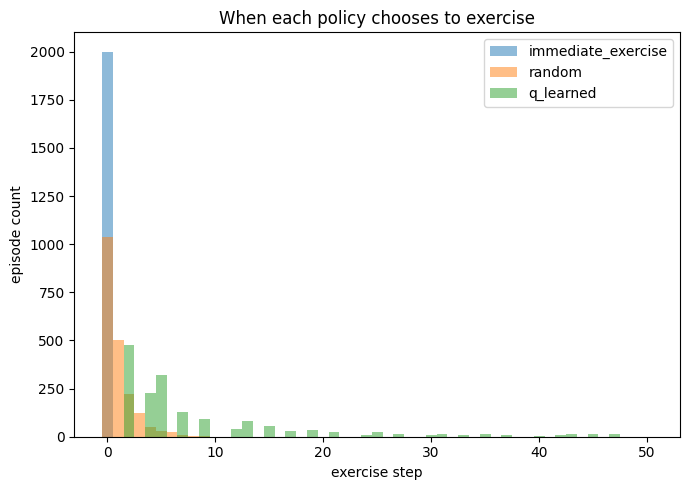

In [8]:
fig = plot_exercise_step_histogram(
    {k: v for k, v in results.items() if k != "always_hold"},
    steps=ENV_KWARGS["steps"],
)
plt.show()


### Exercise-region plot vs. Q-margin plot

Monte Carlo samples are noisy and sparse near any one (time, moneyness) point, so to
compare a policy's *shape* against the exact binomial boundary, each policy is instead
queried directly on a dense, deterministic (time, moneyness) grid.


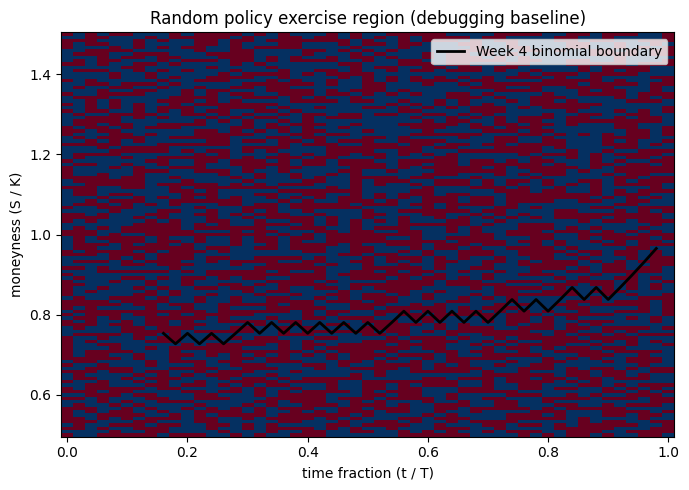

In [9]:
tf, mg, grid = policy_exercise_region(random_policy, ENV_KWARGS["steps"])
fig = plot_exercise_region(
    tf, mg, grid, "Random policy exercise region (debugging baseline)",
    ref_boundary=(ref_t, ref_m),
)
plt.show()


Pure speckle, no structure -- exactly the "should not exercise randomly" pattern
called out as a debugging baseline in the instructional material.


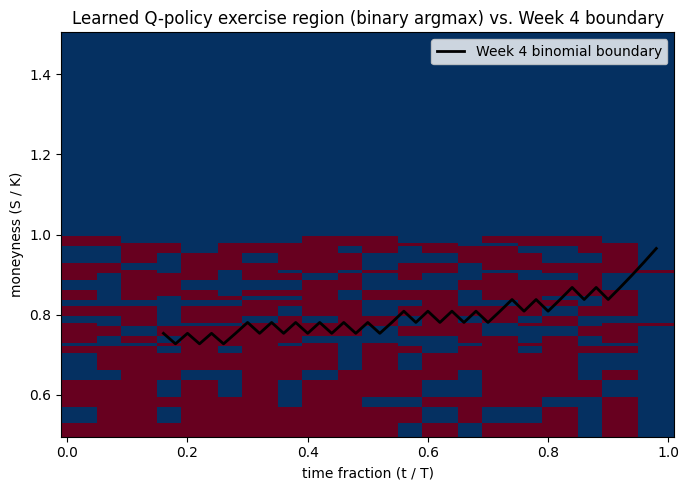

In [10]:
tf, mg, grid = policy_exercise_region(q_policy, ENV_KWARGS["steps"])
fig = plot_exercise_region(
    tf, mg, grid, "Learned Q-policy exercise region (binary argmax) vs. Week 4 boundary",
    ref_boundary=(ref_t, ref_m),
)
plt.show()


This binary decision plot still looks noisy -- a rough cluster of exercise decisions
near the true boundary, but heavy speckle well below it too, essentially the same shape
as the pure-exploring-starts version. The payoff improvement from warmup-then-refine
came from *refined magnitudes*, not a visibly cleaner decision boundary at this
discretization -- which is exactly the motivation for looking at the margin instead of
just the thresholded decision.


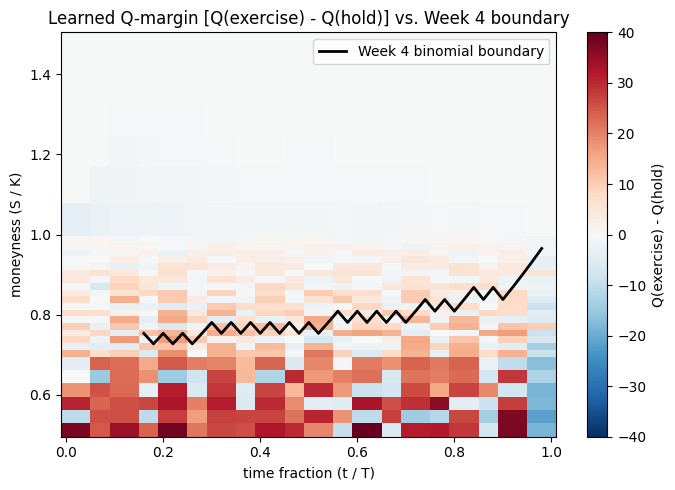

In [11]:
tf, mg, margin = policy_q_margin(Q, ENV_KWARGS["steps"])
fig = plot_q_margin(
    tf, mg, margin, "Learned Q-margin [Q(exercise) - Q(hold)] vs. Week 4 boundary",
    ref_boundary=(ref_t, ref_m),
)
plt.show()


This is the same policy as the binary plot above, but showing `Q(exercise) - Q(hold)`
continuously instead of thresholding it to 0/1. The real structure comes through: the
margin is strongly positive (favors exercise) at low moneyness and grows the deeper
in-the-money it gets, is small and near-zero in a band roughly straddling the true
Week 4 boundary, and turns negative (favors hold) well above the money -- especially
near expiry, bottom-right. That is qualitatively the right shape.

**Why the binary plot looks noisy anyway:** many cells near the true boundary have a
*small* margin, so tiny numerical differences flip their `argmax` sign independently of
their neighbors -- speckle in the thresholded view, even though the underlying value
function is smooth and sensible. A margin plot doesn't hide that noise, it explains it.

**Why warmup-then-refine, not pure exploring starts:** a pure exploring-starts schedule
gets stuck at 3.33 discounted payoff no matter the episode budget (verified above up to
50,000 episodes in earlier testing), because it spreads a fixed budget across all 600
cells instead of concentrating on the region this contract's evaluation actually
depends on. Splitting the schedule -- half the episodes for coverage, half for
targeted refinement at `t=0` -- keeps the 0/600 unvisited-cell guarantee *and* lifts
discounted payoff to 4.17, and unlike pure exploring starts it keeps improving with
more episodes (reaches 5.52 at 50,000 in earlier testing) rather than saturating.


## Reflection

Among the four policies, **always-hold** is still closest to true American put value by
average payoff in this at-the-money example: its discounted mean payoff (7.32) is
within ~8% of the exact binomial American price (7.95), and matches the European price
almost exactly -- correct for a rule that never exercises early. The **tabular
Q-learned** policy is the only one that exercises *selectively* based on moneyness and
time, and with the warmup-then-refine schedule its margin function has the right
qualitative shape across the *entire* state space (full coverage) while landing much
closer to always-hold's payoff (4.17 vs. 7.32, up from 3.33 under pure exploring
starts) -- and, unlike pure exploring starts, it keeps closing that gap with more
training instead of stalling. It still hasn't converged precisely enough to beat
always-hold outright, and its region plot is still visibly speckled near the boundary
even though its margin plot shows the right underlying shape.

That gap -- right shape and full coverage, imprecise value, still improving with more
(but not unlimited) budget -- is the natural motivation for Week 8: replace the table
with a function approximator that gets full coverage *and* sample efficiency at once,
instead of needing a hand-tuned episode-scheduling trick to approximate that trade-off
within a table. The assignment is explicit that Week 7's job is a correct, leak-free
environment and learning loop with a coarse tabular agent as a first prototype -- not a
converged policy -- and the honest trade-offs surfaced above (coverage vs. sample
efficiency, binary decisions vs. margins, and now episode-scheduling vs. a smarter
model) are exactly the kind of environment/agent understanding this week is meant to
build before Week 8 trains something stronger.
